In [34]:
import os
from tensorflow.keras.datasets import imdb

num_words = 10000
(x_train,y_train),(x_test,y_test) = imdb.load_data(num_words=num_words)
print(f"训练集样本数: {len(x_train)}")
print(f"测试集样本数: {len(x_test)}")
print(f"训练集标签示例: {y_train[:10]}")
print(f"测试集标签示例: {y_test[:10]}")
      
word_index = imdb.get_word_index()
word_index = {k:(v+3) for k,v in word_index.items()}
word_index.update({"<PAD>":0,"<START>":1,"<UNK>":2,"<UNUSED>":3})
print(x_train[1])

训练集样本数: 25000
测试集样本数: 25000
训练集标签示例: [1 0 0 1 0 0 1 0 1 0]
测试集标签示例: [0 1 1 0 1 1 1 0 0 1]
[1, 194, 1153, 194, 8255, 78, 228, 5, 6, 1463, 4369, 5012, 134, 26, 4, 715, 8, 118, 1634, 14, 394, 20, 13, 119, 954, 189, 102, 5, 207, 110, 3103, 21, 14, 69, 188, 8, 30, 23, 7, 4, 249, 126, 93, 4, 114, 9, 2300, 1523, 5, 647, 4, 116, 9, 35, 8163, 4, 229, 9, 340, 1322, 4, 118, 9, 4, 130, 4901, 19, 4, 1002, 5, 89, 29, 952, 46, 37, 4, 455, 9, 45, 43, 38, 1543, 1905, 398, 4, 1649, 26, 6853, 5, 163, 11, 3215, 2, 4, 1153, 9, 194, 775, 7, 8255, 2, 349, 2637, 148, 605, 2, 8003, 15, 123, 125, 68, 2, 6853, 15, 349, 165, 4362, 98, 5, 4, 228, 9, 43, 2, 1157, 15, 299, 120, 5, 120, 174, 11, 220, 175, 136, 50, 9, 4373, 228, 8255, 5, 2, 656, 245, 2350, 5, 4, 9837, 131, 152, 491, 18, 2, 32, 7464, 1212, 14, 9, 6, 371, 78, 22, 625, 64, 1382, 9, 8, 168, 145, 23, 4, 1690, 15, 16, 4, 1355, 5, 28, 6, 52, 154, 462, 33, 89, 78, 285, 16, 145, 95]


In [35]:
index_to_word = {v:k for k,v in word_index.items()}
def decode_review(encoded_review):
    return " ".join(index_to_word.get(v,"?") for v in encoded_review)

print(decode_review(x_train[0]))

<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for wha

In [36]:
import numpy as np
x_val = x_test[:10000]
y_val = y_test[:10000]

x_test = x_test[10000:]
y_test = y_test[10000:]

print(f"验证集样本数: {len(x_val)}")
print(f"测试集样本数: {len(x_test)}")
print(f"验证集标签示例: {y_val[:10]}")
print(f"测试集标签示例: {y_test[:10]}")


验证集样本数: 10000
测试集样本数: 15000
验证集标签示例: [0 1 1 0 1 1 1 0 0 1]
测试集标签示例: [1 1 0 1 0 0 1 0 1 1]


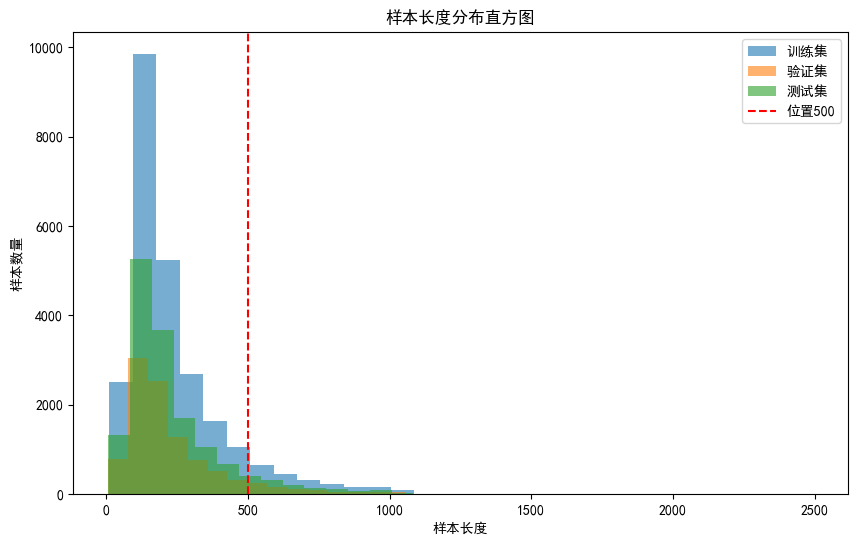

In [37]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei'] # 显示中文标签
matplotlib.rcParams['axes.unicode_minus'] = False   # 正常显示负号

# 计算所有样本的长度
train_lengths = [len(seq) for seq in x_train]
val_lengths = [len(seq) for seq in x_val]
test_lengths = [len(seq) for seq in x_test]

plt.figure(figsize=(10, 6))
plt.hist(train_lengths, bins=30, alpha=0.6, label='训练集')
plt.hist(val_lengths, bins=30, alpha=0.6, label='验证集')
plt.hist(test_lengths, bins=30, alpha=0.6, label='测试集')
plt.axvline(x=500, color='r', linestyle='--', label='位置500')
plt.xlabel('样本长度')
plt.ylabel('样本数量')
plt.title('样本长度分布直方图')
plt.legend()
plt.show()


In [38]:
class Tokenizer:
    def __init__(self, word_index, index_to_word):
        self.word_index = word_index
        self.index_to_word = index_to_word
        self.vocab_size = len(word_index)
        
        self.pad_token = "<PAD>"
        self.bos_token = "<START>"
        self.unk_token = "<UNK>"
        self.eos_token = "<UNUSED>"

        self.pad_id = self.word_index[self.pad_token]
        self.bos_id = self.word_index[self.bos_token]
        self.unk_id = self.word_index[self.unk_token]
        self.eos_id = self.word_index[self.eos_token]
        
    def encode(self, text, maxlen=None, padding='post', truncating='post',add_bos=False, add_eos=False):
        if not isinstance(text, list):
            raise ValueError("输入文本必须是一个字符串列表")
                
        batch_max_len = max([len(seq) for seq in text])  # 计算批次中最长序列的长度
        if add_bos:
            batch_max_len += 1  # 如果添加起始符，最大长度加1
        if add_eos:
            batch_max_len += 1  # 如果添加结束符，最大长度加1
        
        if maxlen is None or maxlen > batch_max_len:
            maxlen = batch_max_len
        
        result = []
        for text in text:
            sequence = []
            
            if add_bos:
                sequence.append(self.bos_id)
            
            for word in text:
                sequence.append(self.word_index.get(word, self.unk_id))
            
            if add_eos:
                sequence.append(self.eos_id)
            
            if len(sequence) > maxlen:
                if truncating == 'post':
                    sequence = sequence[:maxlen]
                elif truncating == 'pre':
                    sequence = sequence[-maxlen:]
            else:
                pad_length = maxlen - len(sequence)
                if pad_length > 0:
                    if padding == 'post':
                        sequence = sequence + [self.pad_id] * pad_length
                    elif padding == 'pre':
                        sequence = [self.pad_id] * pad_length + sequence
                        
            result.append(sequence)
        
        return np.array(result)
    
    def decode(self, ids, skip_special_tokens=True):
        results = []
        special_tokens = {self.pad_token, self.bos_token, self.eos_token}
        for seq in ids:
            tokens = []
            for idx in seq:
                token = self.index_to_word.get(idx, self.unk_token)
                if skip_special_tokens and token in special_tokens:
                    continue
                tokens.append(token)
            results.append(' '.join(tokens))

        return results

raw_text = ["hello world".split(), "tokenize text datas with batch".split(), "this is a test".split()]
tokenizer=Tokenizer(word_index,index_to_word)
encoded_text = tokenizer.encode(raw_text)
decoded_text = tokenizer.decode(encoded_text)

a,b=zip(('a',1),('b',1),('c',0))

In [39]:
import torch
from torch.utils.data import Dataset, DataLoader

class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = tokenizer.decode(texts)
        self.labels = labels
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

def collate_fn(batch,max_len = 500):
    texts, labels = zip(*batch)
    token_lists = [text.split() for text in texts]
    encoded_batch = tokenizer.encode(token_lists,maxlen=max_len)
    return torch.tensor(encoded_batch, dtype=torch.long), torch.tensor(labels, dtype=torch.long)

train_dataset = TextDataset(x_train, y_train)
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)

val_dataset = TextDataset(x_val, y_val)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn)

test_dataset = TextDataset(x_test, y_test)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn)

for batch_texts, batch_labels in train_dataloader:
    print(batch_texts.shape)
    print(batch_labels.shape)
    print(batch_texts)
    print(batch_labels)
    decoded_texts = tokenizer.decode(batch_texts.tolist())
    print(decoded_texts)
    break

for batch_texts, batch_labels in val_dataloader:
    print(batch_texts.shape)
    print(batch_labels.shape)
    break

for batch_texts, batch_labels in test_dataloader:
    print(batch_texts.shape)
    print(batch_labels.shape)
    break

torch.Size([64, 500])
torch.Size([64])
tensor([[ 13, 119,  14,  ...,   0,   0,   0],
        [ 14,   9,   6,  ...,   0,   0,   0],
        [ 17, 230,  17,  ...,   0,   0,   0],
        ...,
        [ 66,   4, 787,  ...,   0,   0,   0],
        [ 14, 218,   6,  ...,   0,   0,   0],
        [  6, 255,   2,  ...,   0,   0,   0]])
tensor([1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
        1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0,
        0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1])
['i love this movie purple rain came out the year i was born and it has had my heart since i can remember prince is so tight in this movie i went to a special showing of purple rain last night and it was like a concert i was glad to see some true fans cause this movie is so <UNK> it is really one of the greatest movies of all time the music is <UNK> the movie is about the kid played by prince his family is dysfunctional his band is the <UNK> act in t

In [40]:
import torch
import torch.nn as nn

class TextClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(embedding_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        embeddings = self.embedding(x)
        embeddings = embeddings.permute(0, 2, 1)
        pooled = self.global_avg_pool(embeddings)
        pooled = pooled.squeeze(-1)
        hidden = torch.relu(self.fc1(pooled))
        return self.fc2(hidden)

vocab_size = num_words
embedding_dim = 100
hidden_dim = 128
num_classes = 1

model = TextClassifier(vocab_size, embedding_dim, hidden_dim, num_classes)

In [41]:
# 编写前向计算验证模型
batch_size = 2
seq_len = 10
x = torch.randint(0, vocab_size, (batch_size, seq_len), dtype=torch.long)
print(x.shape)
with torch.no_grad():
    outputs = model(x)
    print("Output shape:", outputs.shape)
    print("Output:", outputs)
    
    
total_params = 0
for name, param in model.named_parameters():
    num = param.numel()
    print(f"{name}: {num}")
    total_params += num
print("Total trainable parameters:", total_params)

torch.Size([2, 10])
Output shape: torch.Size([2, 1])
Output: tensor([[-0.0741],
        [-0.2115]])
embedding.weight: 1000000
fc1.weight: 12800
fc1.bias: 128
fc2.weight: 128
fc2.bias: 1
Total trainable parameters: 1013057


In [42]:
len(train_dataloader)

391

In [43]:
from torch import device
import my_trainer_RNN as mt

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

early_stopping = mt.EarlyStopping(patience=5, min_delta=0.005,mode='min')

trainer = mt.Trainer(
    model=model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=100,
    early_stopping=early_stopping
)

num_epochs = 20
trainer.train_binary(num_epochs)


[Step 100] Val Loss: 0.6533 Val Acc: 0.6529
[Step 200] Val Loss: 0.5453 Val Acc: 0.7400
[Step 300] Val Loss: 0.4568 Val Acc: 0.7982
Epoch [1/20] Train Loss: 0.5516 Acc: 0.7188 | Val Loss: 0.4568 Val Acc: 0.7982
[Step 400] Val Loss: 0.4056 Val Acc: 0.8263
[Step 500] Val Loss: 0.3755 Val Acc: 0.8383
[Step 600] Val Loss: 0.3569 Val Acc: 0.8494
[Step 700] Val Loss: 0.3420 Val Acc: 0.8569
Epoch [2/20] Train Loss: 0.3320 Acc: 0.8680 | Val Loss: 0.3420 Val Acc: 0.8569
[Step 800] Val Loss: 0.3317 Val Acc: 0.8616
[Step 900] Val Loss: 0.3335 Val Acc: 0.8616
[Step 1000] Val Loss: 0.3164 Val Acc: 0.8709
[Step 1100] Val Loss: 0.3119 Val Acc: 0.8724
Epoch [3/20] Train Loss: 0.2571 Acc: 0.9006 | Val Loss: 0.3119 Val Acc: 0.8724
[Step 1200] Val Loss: 0.3115 Val Acc: 0.8728
[Step 1300] Val Loss: 0.3204 Val Acc: 0.8689
[Step 1400] Val Loss: 0.3082 Val Acc: 0.8758
[Step 1500] Val Loss: 0.3081 Val Acc: 0.8751
Epoch [4/20] Train Loss: 0.2153 Acc: 0.9182 | Val Loss: 0.3081 Val Acc: 0.8751
[Step 1600] Val Lo

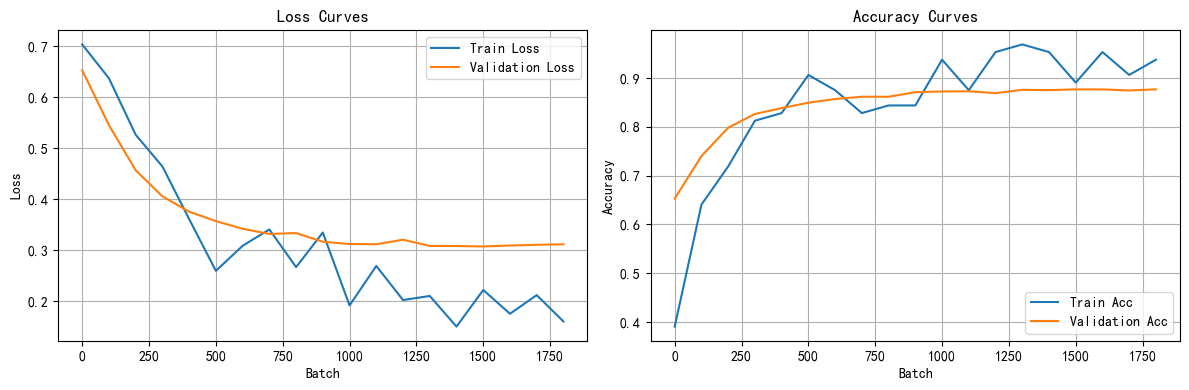

In [44]:
trainer.plot_curves(sample_step=100)

下面是去除early_stopping的训练曲线，从1500左右之后就开始过拟合

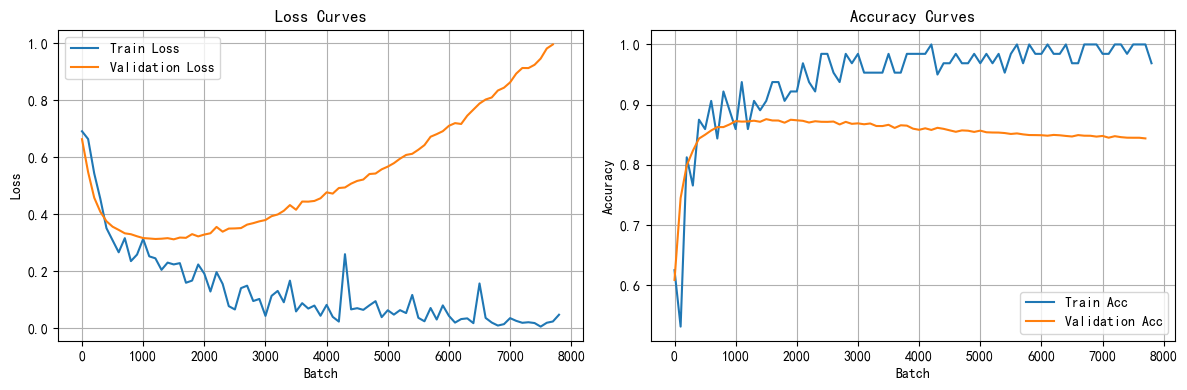

In [33]:
trainer.plot_curves(sample_step=100)